In [1]:
using DataFrames, CSV, Plots
include("/Users/johnbuckner/.julia/dev/UniversalDiffEq.jl/src/UniversalDiffEq.jl")

Main.UniversalDiffEq

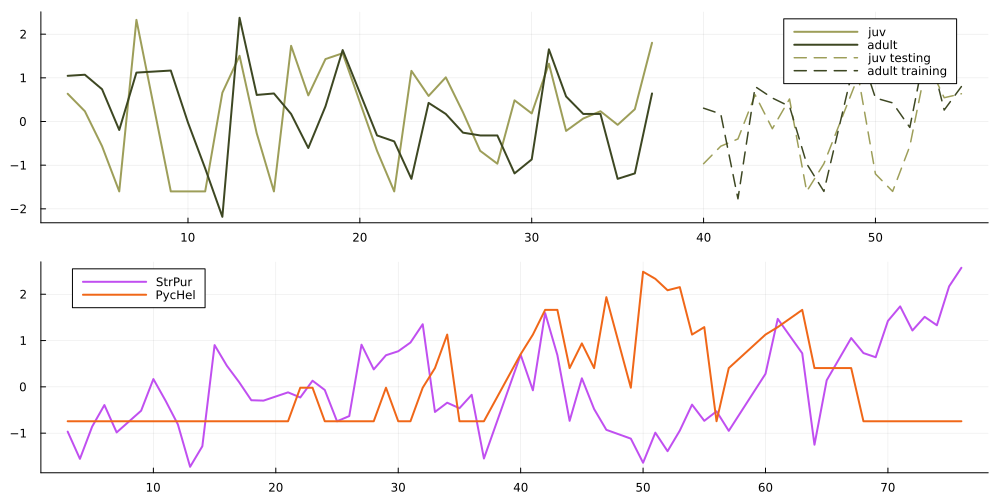

In [2]:
site = 4
dat = CSV.read("../data/processed_time_series.csv", DataFrame)[:,2:end]
dat = sort(dat,:PERIOD)

dat_states = dat[dat.SITE .== site,[:PERIOD,:MacJuv,:MacPyr]]
training = dat_states[dat_states.PERIOD .< 40,:]
testing = dat_states[(dat_states.PERIOD .>= 40) .& (dat_states.PERIOD .<= 55),:]
validation = dat_states[dat_states.PERIOD .> 55,:]

X = dat[dat.SITE .== site,[:PERIOD,:MesFra,:StrPur,:PteCal,:PycHel,:SemPul]]

p1 = Plots.plot(training.PERIOD, training.MacJuv, label = "juv", width = 2, color = "#9d9e59" )
Plots.plot!(training.PERIOD, training.MacPyr, label = "adult", width = 2, color = "#3d4722")
Plots.plot!(testing.PERIOD, testing.MacJuv, label = "juv testing", width = 1.5, linestyle = :dash, color = "#9d9e59")
Plots.plot!(testing.PERIOD, testing.MacPyr, label = "adult training", width = 1.5,linestyle = :dash, color = "#3d4722")
p2 = Plots.plot(X.PERIOD, X.StrPur, label = "StrPur", width = 2, color = "#c04ff0" )
Plots.plot!(X.PERIOD, X.PycHel, label = "PycHel", width = 2, color = "#f06718" )
plot(p1,p2, layout = (2,1), size = (1000,500))

In [3]:
dat_states[1:4,:]

Row,PERIOD,MacJuv,MacPyr
,Int64,Float64,Float64
1,3,0.635984,1.04672
2,4,0.235525,1.07166
3,5,-0.565393,0.739221
4,6,-1.60056,-0.193834


In [4]:
X[1:2,:]

Row,PERIOD,MesFra,StrPur,PteCal,PycHel,SemPul
,Int64,Float64,Float64,Float64,Float64,Float64
1,3,0.481251,-0.966806,0.219836,-0.74234,-1.97455
2,4,-0.0570733,-1.55477,-0.0220743,-0.74234,-2.20364


In [3]:
covars_ma = []
covars_mo = [2,4]

NN_ma, NNparameters_ma = UniversalDiffEq.SimpleNeuralNetwork(1+length(covars_ma),2, hidden = 10, seed = 5491)
NN_mo, NNparameters_mo = UniversalDiffEq.SimpleNeuralNetwork(1+length(covars_mo),2, hidden = 10, seed = 5491)

function dudt(u,X,p,t,covars_ma,covar_mo)
    x_J, x_A = u
    inputs_mo = vcat(u[2:2], X[covars_mo])
    inputs_ma = vcat(u[2:2], X[covars_ma])

    fmo_A, fmo_J = NN_mo(inputs_mo, p.NN_mo)
    fma = NN_ma(inputs_ma, p.NN_ma)[1]

    dJ = exp(p.r)*exp(x_A)*exp(-x_J) - fma - fmo_J
    dA = fma*exp(x_J)*exp(-x_A) - fmo_A
    du = [dJ,dA]

    return du
end

init_parameters = (NN_ma = NNparameters_ma,  NN_mo = NNparameters_mo, r = 0.5)

UDE1 = UniversalDiffEq.CustomDerivatives(training,X,(u,X,p,t) -> dudt(u,X,p,t,covars_ma,covars_mo),
                                            init_parameters;time_column_name = "PERIOD")

UniversalDiffEq.train!(UDE1, loss_function = "spline gradient matching",  #spline 
        regularization_weight = 1e-5, optim_options = (maxiter = 500, step_size = 0.025), 
        loss_options = (σ = 0.05, τ = 0.2, T = 4*size(training)[1]))
nothing

134
47480.85 40751.521 35531.182 31629.292 28842.447 26935.392 25634.264 24656.614 23801.147 22997.614 22261.527 21626.292 21097.426 20636.94 20181.34 19677.081 19103.57 18472.886 17816.341 17170.108 16564.627 16018.44 15536.359 15111.694 14731.555 14383.257 14058.998 13756.611 13476.486 13217.381 12974.624 12741.855 12514.144 12289.439 12067.857 11850.473 11638.718 11433.999 11237.079 11047.735 10865.285 10689.683 10521.954 10363.26 10213.483 10070.929 9933.481 9799.608 9668.264 9538.691 9410.854 9285.32 9162.186 9040.792 8920.755 8802.15 8684.788 8568.666 8454.301 8341.57 8229.756 8118.44 8006.931 7894.8 7782.571 7670.796 7560.715 7453.816 7350.953 7252.497 7157.239 7063.695 6970.353 6876.728 6783.049 6690.221 6599.1 6510.168 6423.206 6337.818 6253.388 6169.584 6086.334 6004.177 5923.709 5845.644 5770.571 5698.88 5630.683 5565.383 5501.214 5436.454 5371.258 5306.639 5242.909 5179.807 5117.231 5055.608 4995.675 4937.898 4882.117 4827.687 4774.022 4721.099 4669.414 4619.503 4571.417 45

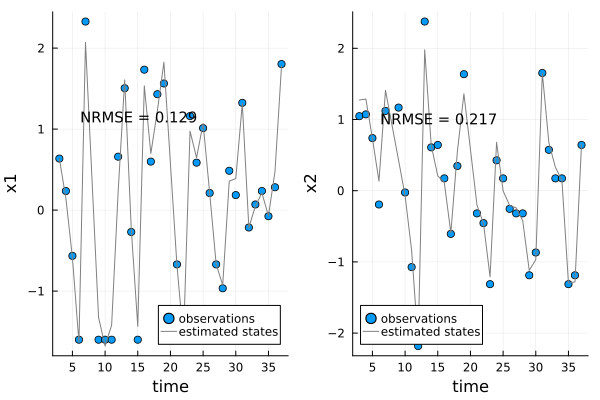

In [5]:
UniversalDiffEq.plot_state_estimates(UDE1)

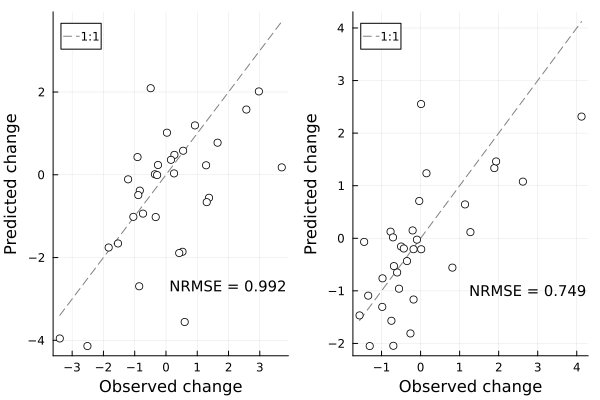

In [6]:
UniversalDiffEq.plot_predictions(UDE1)

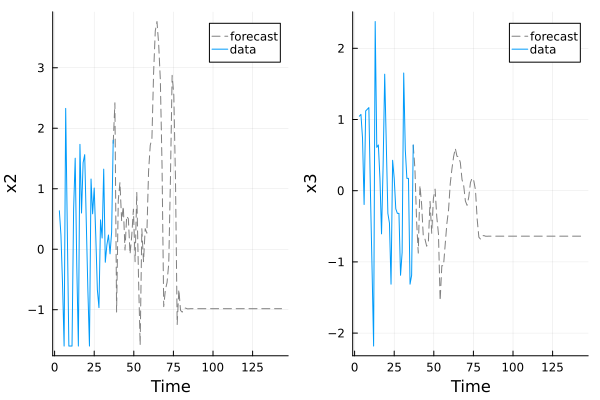

In [34]:
plt,(p1,p2)=UniversalDiffEq.plot_forecast(NODE, 100)
plt

In [89]:
inits,obs,preds = UniversalDiffEq.predictions(NODE,testing)
inits

2×14 Matrix{Float64}:
 -0.965851  -0.565393  -0.399187  0.611396  …  -0.565393  1.38334  0.544916
  0.305698   0.173219  -1.76943   0.800259     -0.135288  1.83848  0.262884

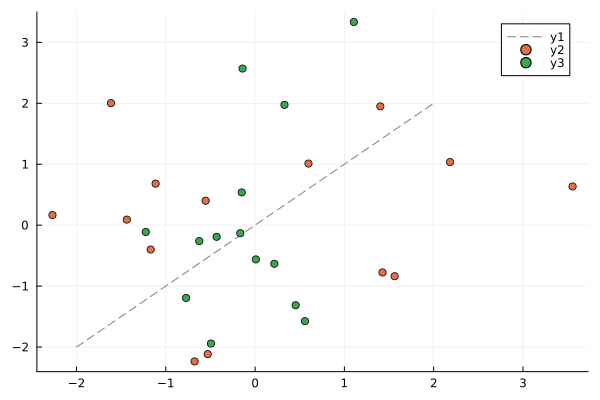

In [91]:
using StatsBase
function test_metrics(model,testing) 
    inits,obs,preds = UniversalDiffEq.predictions(model,testing)
    delta_obs = obs .- inits
    delta_pred = preds .- inits

    plt = Plots.plot([-2,2],[-2,2], color = "grey", linestyle = :dash)
    Plots.scatter!(delta_pred[1,:], delta_obs[1,:])
    Plots.scatter!(delta_pred[2,:], delta_obs[2,:])

    cor_juv = cor(delta_obs[1,:], delta_pred[1,:])
    cor_adult =cor(delta_obs[2,:], delta_pred[2,:])
    return cor_juv, cor_adult, plt
end
c1,c2,plt=test_metrics(NODE,testing)
plt 

In [76]:
function leave_future_out_predict(model, training!, n_per_fold, k_folds)

    training_data = []
    testing_data = []
    data = model.data_frame
    for i in n_per_fold:n_per_fold:(n_per_fold*k_folds)
        push!(training_data, data[1:(end-i),:])
        push!(testing_data, data[(end-i):(end-i+n_per_fold),:]) # including the last data point for one step ahead predictions
    end

    predictions = Array{Any}(nothing, k_folds)
    observations = Array{Any}(nothing, k_folds)
    times = Array{Any}(nothing, k_folds)

    Threads.@threads for i in 1:k_folds
        
        training_i = training_data[i]
        testing_i = testing_data[i]

        model_i = model.constructor(training_i)
        training!(model_i)

        # include first over lapping data point to use for first prediction 
        inits,obs_i,preds_i = UniversalDiffEq.predictions(model_i, testing_i)
        delta_obs = obs_i .- inits
        delta_pred = preds_i .- inits
        predictions[i] =  delta_pred 
        observations[i] =  delta_obs
        times[i] = testing_i[2:end,model.time_column_name]
    end
    
    return predictions,observations,times
end 

leave_future_out_predict (generic function with 1 method)

In [86]:
function training!(model)
    UniversalDiffEq.train!(model, loss_function = "spline gradient matching",  #spline 
        regularization_weight = 1e-5, optim_options = (maxiter = 500, step_size = 0.025), 
        loss_options = (σ = 0.05, τ = 0.1, T = 4*size(training)[1]))
end 

n_per_fold = 4
k_folds = 4
preds, obs, times = leave_future_out_predict(UDE1, training!, n_per_fold , k_folds)

134
101475.393 71541.208 52473.425 42542.15 39007.179 38056.834 36718.758 34163.604 31034.47 28377.133 26957.673 26924.679 27771.607 28642.428 28838.257 28146.437 26812.286 25303.448 24060.4 23327.125 23091.584 23139.596 23191.393 23047.262 22664.94 22142.668 21639.12 21283.107 21115.682 21084.244 21082.899 21012.666 20828.513 20551.841 20248.188 19986.954 19805.63 19695.672 19614.595 19514.649 19370.279 19189.217 19003.336 18847.236 18738.12 18667.952 18610.783 18539.248 18439.575 18316.724 18188.161 18071.646 17975.019 17893.629 17815.719 17731.199 17637.807 17541.197 17449.889 17369.153 17297.981 17230.635 17161.058 17086.787 17009.835 16934.441 16863.686 16797.459 16732.98 16667.148 16598.772 16529.115 16460.555 16394.625 16330.945 16267.735 16203.273 16137.039 16069.746 16002.405 15935.336 15867.919 15799.163 15728.501 15656.102 15582.511 15508.015 15432.347 15354.941 15275.432 15193.903 15110.699 15026.072 14940.024 14852.478 14763.537 14673.527 14582.798 14491.52 14399.736 14307

(Any[[-2.0989510218003797 -2.759107456396829 -1.6586963903585379 -2.257118037164342; -0.1772159134499982 -0.3575876001269126 -1.896998969562152 -3.2567454461650236], [-3.697415356557173 -3.377444710145259 0.2761956516563495 2.538697920539863; -0.7822071907962533 -1.1709213008561954 0.7255554703177751 1.0432733174151725], [-2.8847852079772256 -2.803320822980994 -2.049810105937796 0.7622843872590548; -0.2192277350382351 -0.2518048013137431 0.1433213795930423 0.9252294194571204], [-1.431377353513835 -0.7443659216669898 -1.840222256286701 0.6958184145144845; 0.2605590967499678 0.037217278510431884 1.977451714723838 -0.024613230789969354]], Any[[0.16620545513193702 -0.3113998656757212 0.3576437436674672 1.5215059666592912; 0.0 -1.4859341428028099 0.12478928937385003 1.8304244818678388], [-0.30035287422028 1.1390448873914312 -1.539503774650367 0.284523389482933; 0.3200262558789009 2.521070783395489 -1.078979376506087 -0.40097280933934304], [-0.8009177745178719 -0.881663846195592 -0.295124421

In [87]:
preds_cat = reduce(hcat, preds)
obs_cat = reduce(hcat, obs)
times_cat = reduce(vcat, times)

nms = names(UDE1.data_frame)
nms = nms[nms .!= UDE1.time_column_name]

df_preds = DataFrame(preds_cat', nms)
df_preds[:,UDE1.time_column_name] = times_cat
df_preds = stack(df_preds, nms, value_name = "predicted")

df_obs = DataFrame(obs_cat', nms)
df_obs[:,UDE1.time_column_name] = times_cat
df_obs = stack(df_obs, nms, value_name = "observed")
df = innerjoin(df_obs,df_preds,on = [UDE1.time_column_name,"variable"])
df

Row,PERIOD,variable,observed,predicted
,Int64,String,Float64,Float64
1,34,MacJuv,0.166205,-2.09895
2,35,MacJuv,-0.3114,-2.75911
3,36,MacJuv,0.357644,-1.6587
4,37,MacJuv,1.52151,-2.25712
5,30,MacJuv,-0.300353,-3.69742
6,31,MacJuv,1.13904,-3.37744
7,32,MacJuv,-1.5395,0.276196
8,33,MacJuv,0.284523,2.5387
9,26,MacJuv,-0.800918,-2.88479


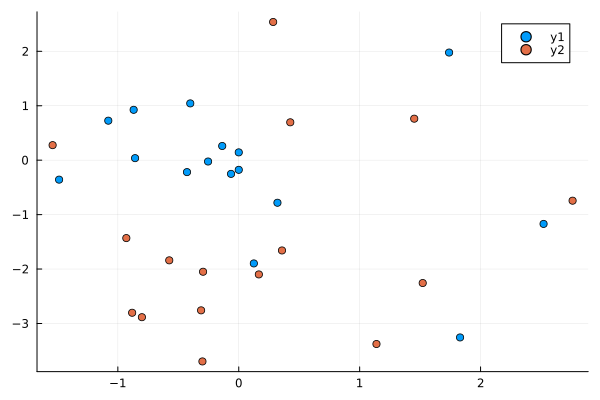

In [88]:
Plots.scatter(df.observed[df.variable.=="MacPyr"], df.predicted[df.variable.=="MacPyr"])
Plots.scatter!(df.observed[df.variable.=="MacJuv"], df.predicted[df.variable.=="MacJuv"])

In [99]:
std(df.predicted)

1.6077019211085637

In [100]:
std(df.observed)

1.0894684896718634

In [103]:
sqrt(mean((df.predicted - df.observed).^2))/std(df.observed)

1.9967291870533366

In [101]:
mean(abs.(df.predicted - df.observed))/std(df.observed)

1.5785734824773616